In [124]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [125]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast
import rasterio as rio
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from sklearn.model_selection import train_test_split

In [126]:
path = Path('data')

# Data exploration

In [145]:
train = pd.read_csv(path / 'train_dataset.csv')
train['last_30_minutes_observation_filename'] = train['last_30_minutes_observation_filename'].apply(lambda x: ast.literal_eval(x))

In [146]:
train

,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
0,c901-207d,aceh,himawari,2023-01-01 00:00:00,"[train_aceh_Himawari_20221231_2330.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_00-00-00.tif
1,3311-9497,aceh,himawari,2023-01-01 00:30:00,"[train_aceh_Himawari_20230101_0000.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_00-30-00.tif
2,ae46-e82d,aceh,himawari,2023-01-01 01:00:00,"[train_aceh_Himawari_20230101_0030.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_01-00-00.tif
3,6ca6-b8d8,aceh,himawari,2023-01-01 01:30:00,"[train_aceh_Himawari_20230101_0100.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_01-30-00.tif
4,20a1-eba0,aceh,himawari,2023-01-01 02:00:00,"[train_aceh_Himawari_20230101_0130.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_02-00-00.tif
...,...,...,...,...,...,...
40681,809d-1213,kinshasa,meteosat,2025-04-30 21:30:00,"[train_kinshasa_Meteosat_20250430_2100.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_21-30-00.tif
40682,711e-f7ac,kinshasa,meteosat,2025-04-30 22:00:00,"[train_kinshasa_Meteosat_20250430_2130.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_22-00-00.tif
40683,f7ce-f8b6,kinshasa,meteosat,2025-04-30 22:30:00,"[train_kinshasa_Meteosat_20250430_2200.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_22-30-00.tif
40684,f232-74eb,kinshasa,meteosat,2025-04-30 23:00:00,"[train_kinshasa_Meteosat_20250430_2230.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_23-00-00.tif


In [147]:
train['last_30_minutes_observation_filename'].apply(lambda x: len(x)).value_counts()

last_30_minutes_observation_filename
3    39796
2      647
0      235
1        8
Name: count, dtype: int64

In [148]:
train['name_location'].value_counts()

name_location
france                   7167
atlantic_coast           2928
ecuador                  2928
aceh                     2926
andalusia                2900
bahia_blanca             1488
bihar                    1488
dhaka                    1488
guangdong                1488
jakarta                  1488
jamaica                  1488
cape_town                1465
gaza_province            1465
florida                  1440
central_philippines      1438
central_vietnam          1438
hat_yai                  1438
friuli_venezia_giulia    1423
kinshasa                 1421
borno_state              1381
Name: count, dtype: int64

In [149]:
train['satellite_target'].value_counts()

satellite_target
meteosat    17222
himawari    13192
goes        10272
Name: count, dtype: int64

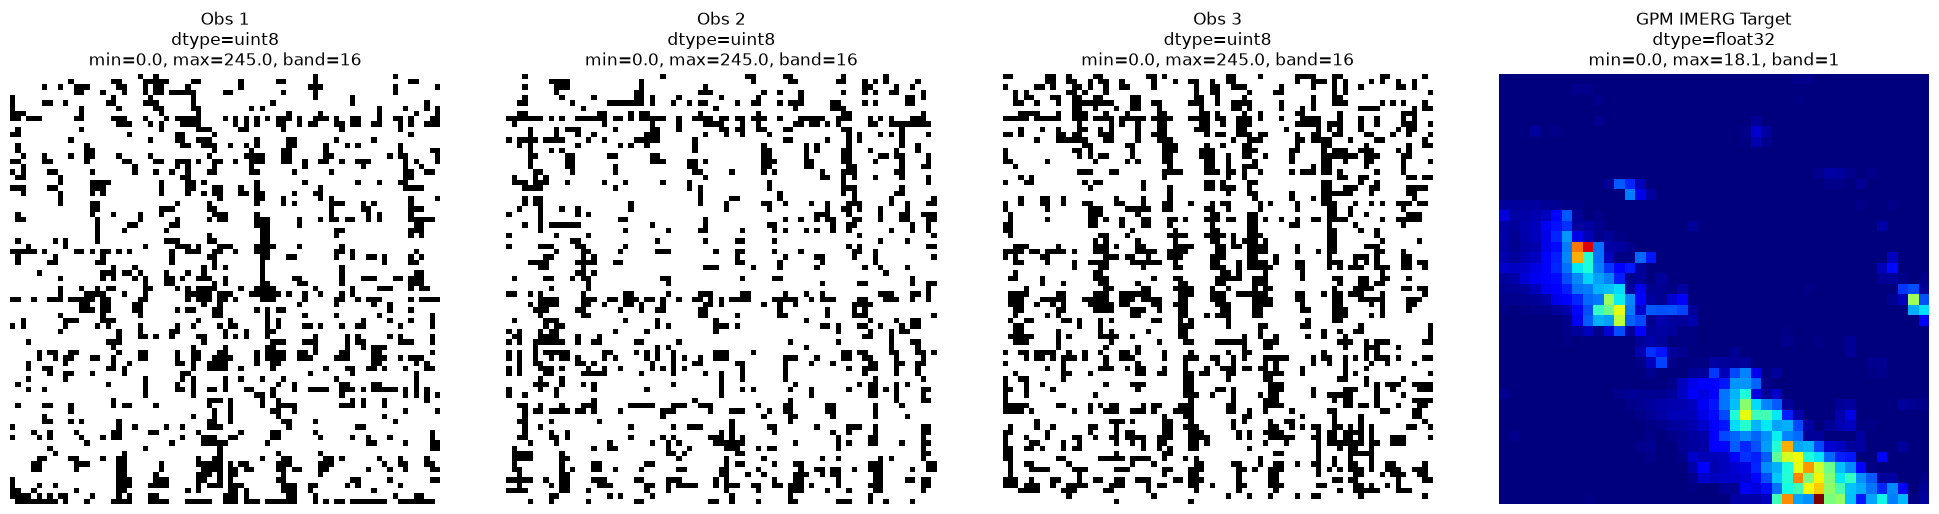

In [150]:
sample = train.sample(1)
obss = sample['last_30_minutes_observation_filename'].values[0]
sat = sample['satellite_target'].values[0]
target = sample['gpm_imerg_filename'].values[0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot the (up to) 3 last_30_minutes_observation files and the target file
for i, obs in enumerate(obss):
    with rio.open(path / sat / obs) as src:
        img = src.read()
        axes[i].imshow(img[0], cmap='gray')
        vmin = img.min()
        vmax = img.max()
        axes[i].set_title(f'Obs {i+1}\ndtype={img.dtype}\nmin={vmin:.1f}, max={vmax:.1f}, band={img.shape[0]}')
   
        axes[i].axis('off')

# Plot the GPM IMERG target
with rio.open(path / 'gpm_imerg' / target) as src:
    target_img = src.read()
    axes[3].imshow(target_img[0], cmap='jet')
    vmin = target_img.min()
    vmax = target_img.max()
    axes[3].set_title(f'GPM IMERG Target\ndtype={target_img.dtype}\nmin={vmin:.1f}, max={vmax:.1f}, band={target_img.shape[0]}')
    axes[3].axis('off')

plt.tight_layout()
plt.show()


Stats

In [151]:
stats = {
    'meteosat': {
        'min': [np.inf]*16,
        'max': [-np.inf]*16,
        'shapes': [],
    },
    'gpm_imerg': {
        'min': np.inf,
        'max': -np.inf,
        'shapes': [],
        # Added for distribution inspection
        'sum': 0.0,
        'sum_sq': 0.0,
        'count': 0,
        'quantiles_accum': [],  # Accumulate flattened values to compute quantiles at end
    },
    'himawari': {
        'min': [np.inf]*16,
        'max': [-np.inf]*16,
        'shapes': [],
    },
    'goes': {
        'min': [np.inf]*16,
        'max': [-np.inf]*16,
        'shapes': [],
    },
}

problem_rows = []

def process_row(idx_row):
    idx, row = idx_row
    row_stats = {
        'sats': {},
        'gpm': {},
        'problem': False  # add marker
    }
    obss = row['last_30_minutes_observation_filename']
    sat = row['satellite_target']
    target = row['gpm_imerg_filename']

    # Per satellite obs
    sat_min = [np.inf] * 16
    sat_max = [-np.inf] * 16
    sat_shapes = []

    for obs in obss:
        with rio.open(path / sat / obs) as src:
            img = src.read()
            # Save row if img does not have 16 bands
            if img.shape[0] != 16:
                row_stats['problem'] = True
            for band in range(img.shape[0]):
                if band < 16: # safe bounds
                    sat_min[band] = min(sat_min[band], img[band].min())
                    sat_max[band] = max(sat_max[band], img[band].max())
            shape = img.shape
            if shape not in sat_shapes:
                sat_shapes.append(shape)
    row_stats['sats'] = {
        'sat': sat,
        'min': sat_min,
        'max': sat_max,
        'shapes': sat_shapes,
    }

    # GPM-IMERG target
    with rio.open(path / 'gpm_imerg' / target) as src:
        img = src.read()
        gpm_min = img.min()
        gpm_max = img.max()
        # For stats & quantiles
        gpm_flat = img.flatten()
        gpm_sum = gpm_flat.sum()
        gpm_sum_sq = (gpm_flat ** 2).sum()
        gpm_count = gpm_flat.size
        shape = img.shape
        gpm_shapes = [shape]
    row_stats['gpm'] = {
        'min': gpm_min,
        'max': gpm_max,
        'shapes': gpm_shapes,
        'sum': gpm_sum,
        'sum_sq': gpm_sum_sq,
        'count': gpm_count,
        'quantiles_accum': gpm_flat
    }
    row_stats['idx'] = idx  # keep track for later
    row_stats['row'] = row  # keep whole row if needed
    return row_stats

from itertools import chain

with ProcessPoolExecutor() as executor:
    future_to_idx = {executor.submit(process_row, (idx, row)): idx for idx, row in tqdm(train.iterrows(), total=len(train))}
    for future in tqdm(as_completed(future_to_idx), total=len(train)):
        row_stats = future.result()
        # Save problematic rows
        if row_stats.get('problem', False):
            problem_rows.append((row_stats['idx'], row_stats['row']))
        sat = row_stats['sats']['sat']
        # For bands
        for band in range(16):
            stats[sat]['min'][band] = min(stats[sat]['min'][band], row_stats['sats']['min'][band])
            stats[sat]['max'][band] = max(stats[sat]['max'][band], row_stats['sats']['max'][band])
        for shape in row_stats['sats']['shapes']:
            if shape not in stats[sat]['shapes']:
                stats[sat]['shapes'].append(shape)
        # GPM-IMERG stats
        stats['gpm_imerg']['min'] = min(stats['gpm_imerg']['min'], row_stats['gpm']['min'])
        stats['gpm_imerg']['max'] = max(stats['gpm_imerg']['max'], row_stats['gpm']['max'])
        for shape in row_stats['gpm']['shapes']:
            if shape not in stats['gpm_imerg']['shapes']:
                stats['gpm_imerg']['shapes'].append(shape)
        # Aggregate for mean/std/quantiles
        stats['gpm_imerg']['sum'] += row_stats['gpm']['sum']
        stats['gpm_imerg']['sum_sq'] += row_stats['gpm']['sum_sq']
        stats['gpm_imerg']['count'] += row_stats['gpm']['count']
        # Accumulate values for quantile calculation
        stats['gpm_imerg']['quantiles_accum'].append(row_stats['gpm']['quantiles_accum'])

# (Optional, in another cell, after this block, you can compute mean, std, quantiles)
# For convenience, here's some code you may use after this block to compute the quantiles:

# Example: after running the full loop above
# import numpy as np
# gpm_vals_all = np.concatenate(stats['gpm_imerg']['quantiles_accum'])
# mean = stats['gpm_imerg']['sum'] / stats['gpm_imerg']['count']
# std = np.sqrt(stats['gpm_imerg']['sum_sq'] / stats['gpm_imerg']['count'] - mean**2)
# quantiles = np.quantile(gpm_vals_all, [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0])

# At this point, problem_rows contains (idx, row) for all rows where at least one obs file does not have 16 bands.
problem_df = pd.DataFrame([row for idx, row in problem_rows])

  0%|          | 0/40686 [00:00<?, ?it/s]

100%|██████████| 40686/40686 [00:19<00:00, 2083.09it/s]


In [152]:
for k, v in stats.items():
    print(k)
    for k2, v2 in v.items():
        print(k2)
        print(v2)
    print('-'*100)

meteosat
min
[np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0)]
max
[np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(239), np.uint8(217), np.uint8(216), np.uint8(218), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255)]
shapes
[(16, 144, 144)]
----------------------------------------------------------------------------------------------------
gpm_imerg
min
0.0
max
96.509995
shapes
[(1, 41, 41)]
sum
1.9737824e+07
sum_sq
1.4031888e+08
count
68393166
quantiles_accum
[array([0.31800002, 0.324     , 0.38500002, ..., 0.36100003, 0.29700002,
       0.32500002], shape=(1681,), dtype=float32), array([0., 0., 0., ..., 0., 0., 0.], shape=(1681,), dtype=float32), array([0., 0., 0., ..., 0., 0., 0.], shape=(1681,), dtype=float32), array([0., 0., 0., ..., 0

In [135]:
problem_df

,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
7286,02a7-c0db,atlantic_coast,goes,2024-08-31 10:00:00,"[train_atlantic_coast_GOES_20240831_0930.tif, ...",train_atlantic_coast_GPM_IMERG_2024-08-31_10-0...
8728,f6d1-a3bb,atlantic_coast,goes,2024-09-30 11:00:00,"[train_atlantic_coast_GOES_20240930_1030.tif, ...",train_atlantic_coast_GPM_IMERG_2024-09-30_11-0...
8889,fa63-d692,bahia_blanca,goes,2025-03-03 19:30:00,"[train_bahia_blanca_GOES_20250303_1900.tif, tr...",train_bahia_blanca_GPM_IMERG_2025-03-03_19-30-...
9602,4a98-7da5,bahia_blanca,goes,2025-03-18 16:00:00,"[train_bahia_blanca_GOES_20250318_1530.tif, tr...",train_bahia_blanca_GPM_IMERG_2025-03-18_16-00-...
19075,fd09-bdb7,ecuador,goes,2025-03-03 19:30:00,"[train_ecuador_GOES_20250303_1900.tif, train_e...",train_ecuador_GPM_IMERG_2025-03-03_19-30-00.tif
19788,3017-0af7,ecuador,goes,2025-03-18 16:00:00,"[train_ecuador_GOES_20250318_1530.tif, train_e...",train_ecuador_GPM_IMERG_2025-03-18_16-00-00.tif
23282,0f21-8aed,florida,goes,2024-09-30 11:00:00,"[train_florida_GOES_20240930_1030.tif, train_f...",train_florida_GPM_IMERG_2024-09-30_11-00-00.tif
38722,c0ad-2cfd,jamaica,goes,2025-10-20 16:30:00,"[train_jamaica_GOES_20251020_1600.tif, train_j...",train_jamaica_GPM_IMERG_2025-10-20_16-30-00.tif
38767,9d91-9034,jamaica,goes,2025-10-21 15:00:00,"[train_jamaica_GOES_20251021_1430.tif, train_j...",train_jamaica_GPM_IMERG_2025-10-21_15-00-00.tif


In [138]:
# Remove rows in train with id from problem_df
if not problem_df.empty:
    if 'unique_id' in problem_df.columns:
        train = train[~train['unique_id'].isin(problem_df['unique_id'])]

train.to_csv(path / 'train_clean.csv', index=False)

In [139]:
train

,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
0,c901-207d,aceh,himawari,2023-01-01 00:00:00,"[train_aceh_Himawari_20221231_2330.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_00-00-00.tif
1,3311-9497,aceh,himawari,2023-01-01 00:30:00,"[train_aceh_Himawari_20230101_0000.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_00-30-00.tif
2,ae46-e82d,aceh,himawari,2023-01-01 01:00:00,"[train_aceh_Himawari_20230101_0030.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_01-00-00.tif
3,6ca6-b8d8,aceh,himawari,2023-01-01 01:30:00,"[train_aceh_Himawari_20230101_0100.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_01-30-00.tif
4,20a1-eba0,aceh,himawari,2023-01-01 02:00:00,"[train_aceh_Himawari_20230101_0130.tif, train_...",train_aceh_GPM_IMERG_2023-01-01_02-00-00.tif
...,...,...,...,...,...,...
40681,809d-1213,kinshasa,meteosat,2025-04-30 21:30:00,"[train_kinshasa_Meteosat_20250430_2100.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_21-30-00.tif
40682,711e-f7ac,kinshasa,meteosat,2025-04-30 22:00:00,"[train_kinshasa_Meteosat_20250430_2130.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_22-00-00.tif
40683,f7ce-f8b6,kinshasa,meteosat,2025-04-30 22:30:00,"[train_kinshasa_Meteosat_20250430_2200.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_22-30-00.tif
40684,f232-74eb,kinshasa,meteosat,2025-04-30 23:00:00,"[train_kinshasa_Meteosat_20250430_2230.tif, tr...",train_kinshasa_GPM_IMERG_2025-04-30_23-00-00.tif


In [153]:
# 1. Concatenate all accumulated GPM values into a single flat array
gpm_vals_all = np.concatenate(stats['gpm_imerg']['quantiles_accum'])

# 2. Compute Mean and Standard Deviation using the accumulated sum and sum of squares
total_count = stats['gpm_imerg']['count']
mean_val = stats['gpm_imerg']['sum'] / total_count
var_val = (stats['gpm_imerg']['sum_sq'] / total_count) - (mean_val ** 2)
std_val = np.sqrt(max(0.0, var_val))  # max(0, ...) prevents tiny negative numbers due to float precision

# 3. Define the quantiles to compute (including extreme high-end rain rates like 99.9%)
quantile_probs = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]
quantiles = np.quantile(gpm_vals_all, quantile_probs)

# 4. Print the results beautifully
print("=" * 50)
print("          GPM_IMERG TARGET STATISTICS          ")
print("=" * 50)
print(f"Total Pixels Analyzed: {total_count:,}")
print(f"Mean Rain Rate:        {mean_val:.6f}")
print(f"Std Dev Rain Rate:     {std_val:.6f}")
print("-" * 50)
print("QUANTILES:")
for prob, q_val in zip(quantile_probs, quantiles):
    print(f"  {prob * 100:>5.1f}%: {q_val:.6f}")
print("=" * 50)

          GPM_IMERG TARGET STATISTICS          
Total Pixels Analyzed: 68,393,166
Mean Rain Rate:        0.288594
Std Dev Rain Rate:     1.402984
--------------------------------------------------
QUANTILES:
    0.0%: 0.000000
   10.0%: 0.000000
   25.0%: 0.000000
   50.0%: 0.000000
   75.0%: 0.000000
   90.0%: 0.420000
   95.0%: 1.560000
   99.0%: 6.060000
   99.9%: 18.289999
  100.0%: 96.509995


In [ ]:
evaluation = pd.read_csv(path / 'evaluation_target.csv')

In [11]:
evaluation

,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
0,d89c-865b,kanto_region,himawari,2023-01-01 00:00:00,['test_kanto_region_Himawari_20221231_2330.tif...,test_kanto_region_GPM_IMERG_2023-01-01_00-00-0...
1,4372-d9ff,kanto_region,himawari,2023-01-01 00:30:00,['test_kanto_region_Himawari_20230101_0000.tif...,test_kanto_region_GPM_IMERG_2023-01-01_00-30-0...
2,c085-cb78,kanto_region,himawari,2023-01-01 01:00:00,['test_kanto_region_Himawari_20230101_0030.tif...,test_kanto_region_GPM_IMERG_2023-01-01_01-00-0...
3,04f9-69bb,kanto_region,himawari,2023-01-01 01:30:00,['test_kanto_region_Himawari_20230101_0100.tif...,test_kanto_region_GPM_IMERG_2023-01-01_01-30-0...
4,7891-4979,kanto_region,himawari,2023-01-01 02:00:00,['test_kanto_region_Himawari_20230101_0130.tif...,test_kanto_region_GPM_IMERG_2023-01-01_02-00-0...
...,...,...,...,...,...,...
29085,6b66-e372,valencia,meteosat,2025-12-31 21:30:00,"['test_valencia_Meteosat_20251231_2100.tif', '...",test_valencia_GPM_IMERG_2025-12-31_21-30-00.tif
29086,c27c-142b,valencia,meteosat,2025-12-31 22:00:00,"['test_valencia_Meteosat_20251231_2130.tif', '...",test_valencia_GPM_IMERG_2025-12-31_22-00-00.tif
29087,9a7e-fa48,valencia,meteosat,2025-12-31 22:30:00,"['test_valencia_Meteosat_20251231_2200.tif', '...",test_valencia_GPM_IMERG_2025-12-31_22-30-00.tif
29088,b8aa-832a,valencia,meteosat,2025-12-31 23:00:00,"['test_valencia_Meteosat_20251231_2230.tif', '...",test_valencia_GPM_IMERG_2025-12-31_23-00-00.tif


29090 muestras para evaluar. Cada muestra es de una región, con un solo `satellite_target` y hast 3 observaciones. 

In [28]:
observations_count = evaluation['last_30_minutes_observation_filename'].apply(lambda x: len(ast.literal_eval(x)))
observations_count.value_counts()

last_30_minutes_observation_filename
3    28486
2      567
0       29
1        8
Name: count, dtype: int64

# Train-test split

In [140]:
train = pd.read_csv(path / 'train_clean.csv')
train

,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
0,c901-207d,aceh,himawari,2023-01-01 00:00:00,"['train_aceh_Himawari_20221231_2330.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-00-00.tif
1,3311-9497,aceh,himawari,2023-01-01 00:30:00,"['train_aceh_Himawari_20230101_0000.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-30-00.tif
2,ae46-e82d,aceh,himawari,2023-01-01 01:00:00,"['train_aceh_Himawari_20230101_0030.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_01-00-00.tif
3,6ca6-b8d8,aceh,himawari,2023-01-01 01:30:00,"['train_aceh_Himawari_20230101_0100.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_01-30-00.tif
4,20a1-eba0,aceh,himawari,2023-01-01 02:00:00,"['train_aceh_Himawari_20230101_0130.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_02-00-00.tif
...,...,...,...,...,...,...
40672,809d-1213,kinshasa,meteosat,2025-04-30 21:30:00,"['train_kinshasa_Meteosat_20250430_2100.tif', ...",train_kinshasa_GPM_IMERG_2025-04-30_21-30-00.tif
40673,711e-f7ac,kinshasa,meteosat,2025-04-30 22:00:00,"['train_kinshasa_Meteosat_20250430_2130.tif', ...",train_kinshasa_GPM_IMERG_2025-04-30_22-00-00.tif
40674,f7ce-f8b6,kinshasa,meteosat,2025-04-30 22:30:00,"['train_kinshasa_Meteosat_20250430_2200.tif', ...",train_kinshasa_GPM_IMERG_2025-04-30_22-30-00.tif
40675,f232-74eb,kinshasa,meteosat,2025-04-30 23:00:00,"['train_kinshasa_Meteosat_20250430_2230.tif', ...",train_kinshasa_GPM_IMERG_2025-04-30_23-00-00.tif


In [141]:
train_split, test_split = train_test_split(train, test_size=0.2, random_state=42, stratify=train['name_location'])
train_split.to_csv(path / 'train_split.csv', index=False)
test_split.to_csv(path / 'test_split.csv', index=False)

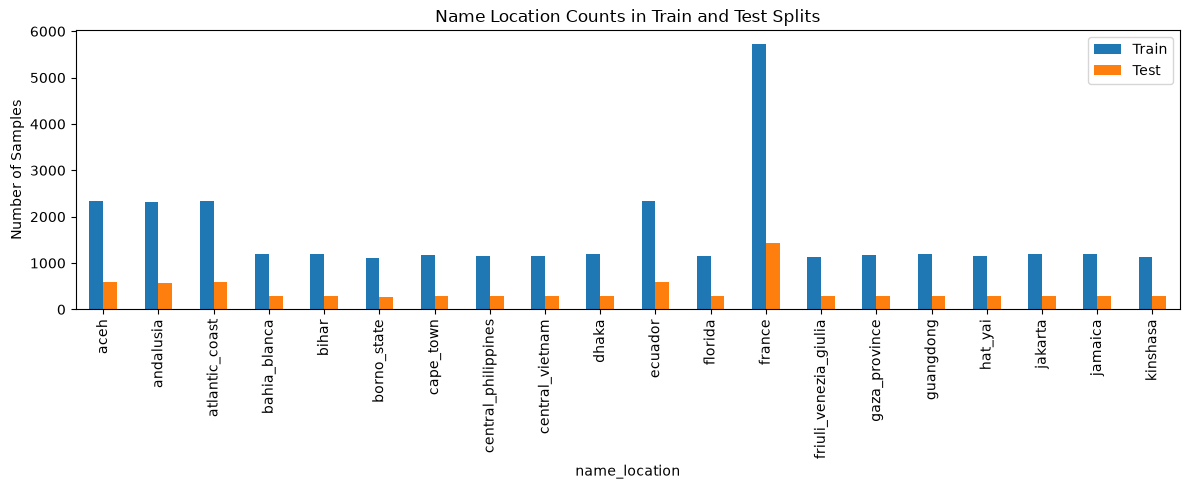

In [142]:
# Plot train and test split together for name_location
train_name_counts = train_split.name_location.value_counts().sort_index()
test_name_counts = test_split.name_location.value_counts().sort_index()

df_name_counts = pd.DataFrame({
    'train': train_name_counts,
    'test': test_name_counts
}).fillna(0).astype(int)

df_name_counts.plot(kind='bar', figsize=(12,5))
plt.title("Name Location Counts in Train and Test Splits")
plt.xlabel("name_location")
plt.ylabel("Number of Samples")
plt.legend(["Train", "Test"])
plt.tight_layout()
plt.show()

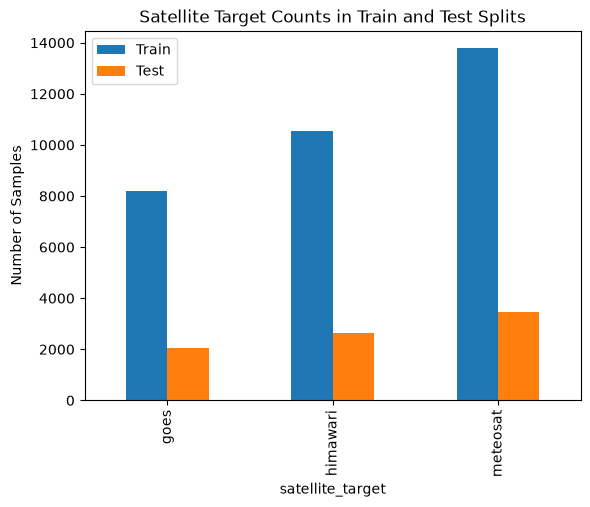

In [143]:
# Plot train and test split together for satellite_target
train_counts = train_split.satellite_target.value_counts().sort_index()
test_counts = test_split.satellite_target.value_counts().sort_index()

df_counts = pd.DataFrame({
    'train': train_counts,
    'test': test_counts
}).fillna(0).astype(int)

df_counts.plot(kind='bar')
plt.title("Satellite Target Counts in Train and Test Splits")
plt.xlabel("satellite_target")
plt.ylabel("Number of Samples")
plt.legend(["Train", "Test"])
plt.show()